In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation

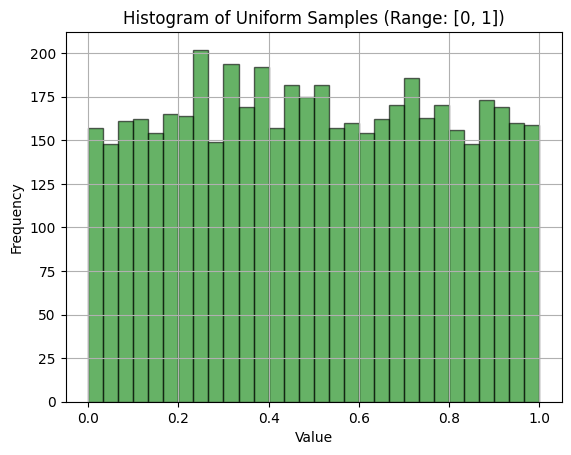

In [2]:
batch_size = 5000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

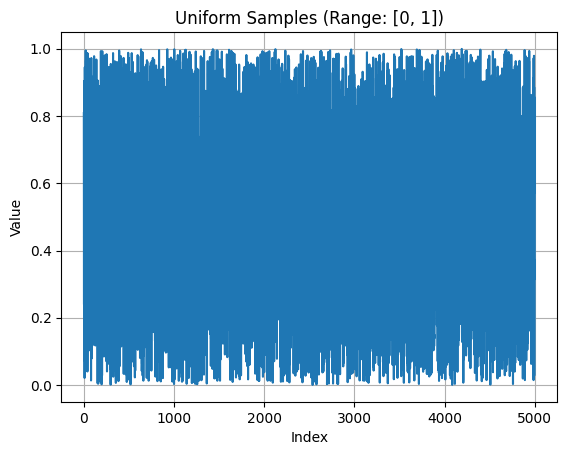

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

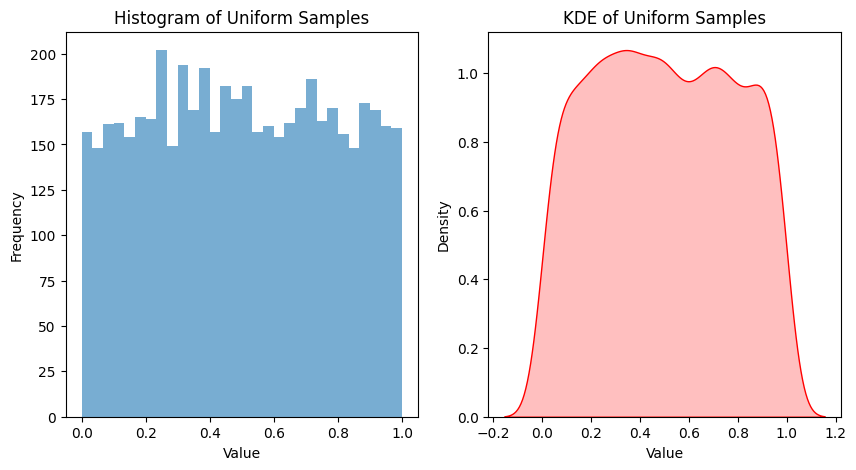

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

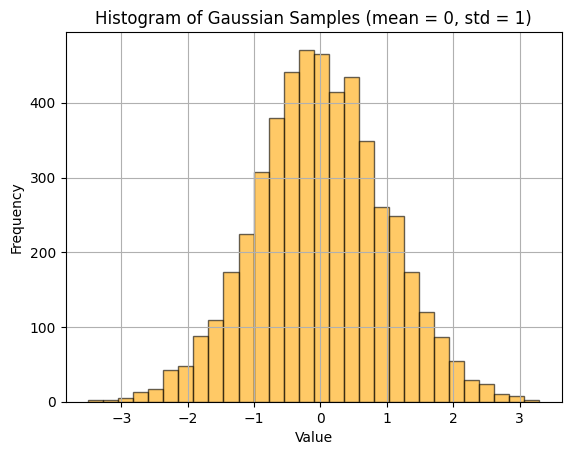

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

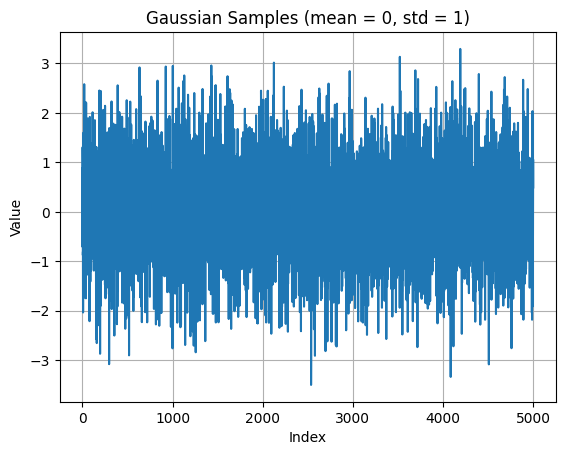

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

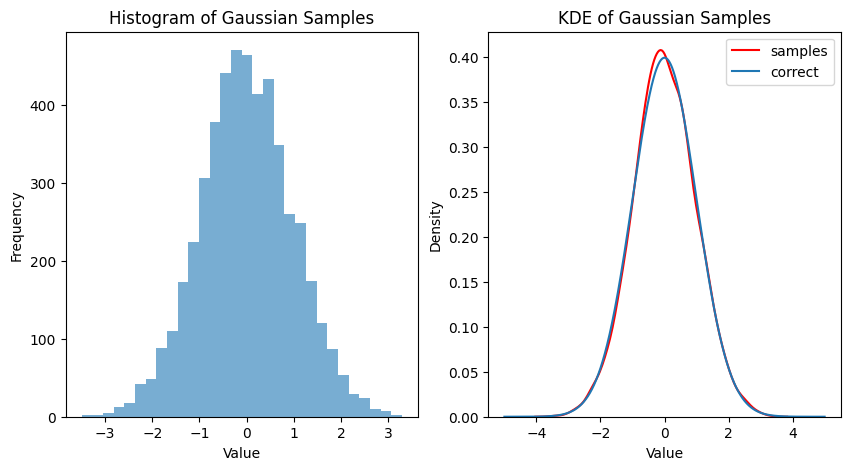

In [7]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

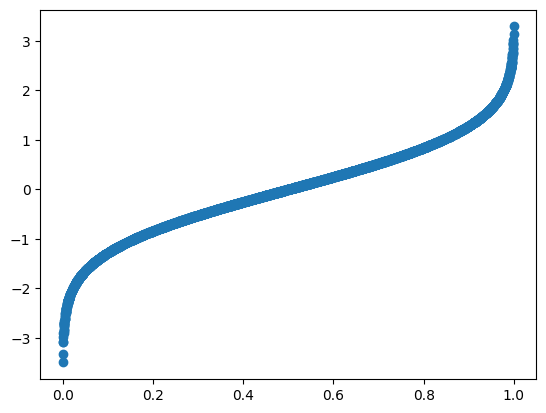

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 256)
        self.fc4 = nn.Linear(256, 256)
        self.fc5 = nn.Linear(256, 256)
        self.fc6 = nn.Linear(256, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
def compute_skewness(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    return skewness

In [15]:
def compute_kurtosis(samples):
    mean = compute_mean(samples)
    variance = compute_variance(samples)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    return kurtosis

In [16]:
def compute_fifth_moment(samples):
    mean = compute_mean(samples)
    fifth_moment = torch.mean((samples - mean) ** 5)
    return fifth_moment

In [17]:
def compute_sixth_moment(samples):
    mean = compute_mean(samples)
    return torch.mean((samples - mean) ** 6)

In [18]:
# Initialize the neural network
model = FNN()

In [19]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
mean_loss_list = []
variance_loss_list = []
skewness_loss_list = []
kurtosis_loss_list = []
fifth_moment_loss_list = []
sixth_moment_loss_list = []
total_loss_list = []
epoch_list = []

# Training loop
num_epochs = 20000
save_interval = 50  # Save model every 50 iterations

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(uniform_samples)
    
    # Compute individual moment losses
    mean_loss = torch.abs(compute_mean(outputs) - compute_mean(gaussian_samples)) 
    variance_loss = torch.abs(compute_variance(outputs) - compute_variance(gaussian_samples))
    skewness_loss = torch.abs(compute_skewness(outputs) - compute_skewness(gaussian_samples))
    kurtosis_loss = torch.abs(compute_kurtosis(outputs) - compute_kurtosis(gaussian_samples))
    fifth_moment_loss = torch.abs(compute_fifth_moment(outputs) - compute_fifth_moment(gaussian_samples))
    sixth_moment_loss = torch.abs(compute_sixth_moment(outputs) - compute_sixth_moment(gaussian_samples))

    # Total loss with weighted moments
    total_loss = (50 * mean_loss + 50 * variance_loss + 10 * skewness_loss + 
                  10 * kurtosis_loss + fifth_moment_loss + sixth_moment_loss)

    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    mean_loss_list.append(mean_loss.item())
    variance_loss_list.append(variance_loss.item())
    skewness_loss_list.append(skewness_loss.item())
    kurtosis_loss_list.append(kurtosis_loss.item())
    fifth_moment_loss_list.append(fifth_moment_loss.item())
    sixth_moment_loss_list.append(sixth_moment_loss.item())
    total_loss_list.append(total_loss.item())
    epoch_list.append(epoch + 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Mean Loss: {mean_loss.item():.5f}, '
          f'Variance Loss: {variance_loss.item():.5f}, Skewness Loss: {skewness_loss.item():.6f}, '
          f'Kurtosis Loss: {kurtosis_loss.item():.6f}, Fifth Moment Loss: {fifth_moment_loss.item():.5f}, '
          f'Sixth Moment Loss: {sixth_moment_loss.item():.5f}')
    
    # Save model every 10 iterations
    if (epoch + 1) % save_interval == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        print(f"Model saved at epoch {epoch+1}")
        
    # Early stopping condition
    if (total_loss<=1):
#     if (mean_loss <= 0.0005 and variance_loss <= 0.0005 and skewness_loss <= 0.005 and 
#         kurtosis_loss <= 0.005 and fifth_moment_loss <= 0.1 and sixth_moment_loss <= 0.5):
        print(f"Early stopping at epoch {epoch + 1}")
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        break


Epoch [1/20000], Mean Loss: 0.01182, Variance Loss: 0.95699, Skewness Loss: 0.234577, Kurtosis Loss: 1.178799, Fifth Moment Loss: 0.00924, Sixth Moment Loss: 12.61807
Epoch [2/20000], Mean Loss: 0.11470, Variance Loss: 0.94416, Skewness Loss: 0.043101, Kurtosis Loss: 1.197791, Fifth Moment Loss: 0.00925, Sixth Moment Loss: 12.61806
Epoch [3/20000], Mean Loss: 0.33617, Variance Loss: 0.92440, Skewness Loss: 0.198611, Kurtosis Loss: 1.148829, Fifth Moment Loss: 0.00942, Sixth Moment Loss: 12.61792
Epoch [4/20000], Mean Loss: 0.18475, Variance Loss: 0.91457, Skewness Loss: 0.131077, Kurtosis Loss: 1.183487, Fifth Moment Loss: 0.00948, Sixth Moment Loss: 12.61776
Epoch [5/20000], Mean Loss: 0.12529, Variance Loss: 0.90883, Skewness Loss: 0.001748, Kurtosis Loss: 1.218432, Fifth Moment Loss: 0.00929, Sixth Moment Loss: 12.61765
Epoch [6/20000], Mean Loss: 0.17090, Variance Loss: 0.89794, Skewness Loss: 0.035569, Kurtosis Loss: 1.227124, Fifth Moment Loss: 0.00919, Sixth Moment Loss: 12.6173

Epoch [50/20000], Mean Loss: 0.13887, Variance Loss: 0.00478, Skewness Loss: 0.049466, Kurtosis Loss: 1.325158, Fifth Moment Loss: 0.25548, Sixth Moment Loss: 9.69842
Model saved at epoch 50
Epoch [51/20000], Mean Loss: 0.04474, Variance Loss: 0.11023, Skewness Loss: 0.012959, Kurtosis Loss: 1.323847, Fifth Moment Loss: 0.09485, Sixth Moment Loss: 10.62713
Epoch [52/20000], Mean Loss: 0.09342, Variance Loss: 0.12228, Skewness Loss: 0.043273, Kurtosis Loss: 1.324900, Fifth Moment Loss: 0.04814, Sixth Moment Loss: 10.71539
Epoch [53/20000], Mean Loss: 0.15345, Variance Loss: 0.03775, Skewness Loss: 0.067537, Kurtosis Loss: 1.328311, Fifth Moment Loss: 0.14025, Sixth Moment Loss: 10.08672
Epoch [54/20000], Mean Loss: 0.13880, Variance Loss: 0.17101, Skewness Loss: 0.061799, Kurtosis Loss: 1.340287, Fifth Moment Loss: 0.20841, Sixth Moment Loss: 8.01967
Epoch [55/20000], Mean Loss: 0.04781, Variance Loss: 0.27303, Skewness Loss: 0.026481, Kurtosis Loss: 1.346998, Fifth Moment Loss: 0.03238

Epoch [100/20000], Mean Loss: 0.09603, Variance Loss: 0.04150, Skewness Loss: 0.036666, Kurtosis Loss: 1.327374, Fifth Moment Loss: 0.18660, Sixth Moment Loss: 10.11055
Model saved at epoch 100
Epoch [101/20000], Mean Loss: 0.02881, Variance Loss: 0.19105, Skewness Loss: 0.006920, Kurtosis Loss: 1.344193, Fifth Moment Loss: 0.15554, Sixth Moment Loss: 7.79709
Epoch [102/20000], Mean Loss: 0.11476, Variance Loss: 0.31963, Skewness Loss: 0.049921, Kurtosis Loss: 1.351943, Fifth Moment Loss: 0.20208, Sixth Moment Loss: 6.06343
Epoch [103/20000], Mean Loss: 0.17336, Variance Loss: 0.32511, Skewness Loss: 0.072388, Kurtosis Loss: 1.350764, Fifth Moment Loss: 0.36440, Sixth Moment Loss: 5.96123
Epoch [104/20000], Mean Loss: 0.14789, Variance Loss: 0.22481, Skewness Loss: 0.062636, Kurtosis Loss: 1.347075, Fifth Moment Loss: 0.23949, Sixth Moment Loss: 7.37992
Epoch [105/20000], Mean Loss: 0.05873, Variance Loss: 0.04902, Skewness Loss: 0.027407, Kurtosis Loss: 1.339692, Fifth Moment Loss: 0.

Epoch [151/20000], Mean Loss: 0.03003, Variance Loss: 0.19720, Skewness Loss: 0.009401, Kurtosis Loss: 1.324273, Fifth Moment Loss: 0.06754, Sixth Moment Loss: 11.18088
Epoch [152/20000], Mean Loss: 0.03475, Variance Loss: 0.19491, Skewness Loss: 0.018475, Kurtosis Loss: 1.325921, Fifth Moment Loss: 0.01269, Sixth Moment Loss: 11.17235
Epoch [153/20000], Mean Loss: 0.04722, Variance Loss: 0.12531, Skewness Loss: 0.024608, Kurtosis Loss: 1.330551, Fifth Moment Loss: 0.00163, Sixth Moment Loss: 10.75114
Epoch [154/20000], Mean Loss: 0.00634, Variance Loss: 0.02605, Skewness Loss: 0.008894, Kurtosis Loss: 1.339470, Fifth Moment Loss: 0.05077, Sixth Moment Loss: 9.57273
Epoch [155/20000], Mean Loss: 0.07975, Variance Loss: 0.10358, Skewness Loss: 0.026028, Kurtosis Loss: 1.340901, Fifth Moment Loss: 0.21519, Sixth Moment Loss: 8.79554
Epoch [156/20000], Mean Loss: 0.10096, Variance Loss: 0.08966, Skewness Loss: 0.035232, Kurtosis Loss: 1.338859, Fifth Moment Loss: 0.24856, Sixth Moment Los

Epoch [201/20000], Mean Loss: 0.06783, Variance Loss: 0.05615, Skewness Loss: 0.030304, Kurtosis Loss: 1.330199, Fifth Moment Loss: 0.02121, Sixth Moment Loss: 10.24446
Epoch [202/20000], Mean Loss: 0.02952, Variance Loss: 0.06762, Skewness Loss: 0.014063, Kurtosis Loss: 1.329013, Fifth Moment Loss: 0.02697, Sixth Moment Loss: 10.33000
Epoch [203/20000], Mean Loss: 0.05275, Variance Loss: 0.00382, Skewness Loss: 0.019453, Kurtosis Loss: 1.330564, Fifth Moment Loss: 0.14856, Sixth Moment Loss: 9.73572
Epoch [204/20000], Mean Loss: 0.07893, Variance Loss: 0.00137, Skewness Loss: 0.030481, Kurtosis Loss: 1.328592, Fifth Moment Loss: 0.18517, Sixth Moment Loss: 9.77241
Epoch [205/20000], Mean Loss: 0.05721, Variance Loss: 0.08492, Skewness Loss: 0.020677, Kurtosis Loss: 1.334674, Fifth Moment Loss: 0.18436, Sixth Moment Loss: 8.96335
Epoch [206/20000], Mean Loss: 0.01579, Variance Loss: 0.08723, Skewness Loss: 0.008817, Kurtosis Loss: 1.337067, Fifth Moment Loss: 0.05785, Sixth Moment Loss

...

Epoch [13043/20000], Mean Loss: 0.00286, Variance Loss: 0.02643, Skewness Loss: 0.021073, Kurtosis Loss: 0.044155, Fifth Moment Loss: 0.11137, Sixth Moment Loss: 1.79853
Epoch [13044/20000], Mean Loss: 0.00634, Variance Loss: 0.03040, Skewness Loss: 0.027812, Kurtosis Loss: 0.043730, Fifth Moment Loss: 0.15085, Sixth Moment Loss: 1.93417
Epoch [13045/20000], Mean Loss: 0.00020, Variance Loss: 0.00514, Skewness Loss: 0.018097, Kurtosis Loss: 0.026036, Fifth Moment Loss: 0.09765, Sixth Moment Loss: 1.19187
Epoch [13046/20000], Mean Loss: 0.01410, Variance Loss: 0.04844, Skewness Loss: 0.005731, Kurtosis Loss: 0.005493, Fifth Moment Loss: 0.06217, Sixth Moment Loss: 0.51761
Epoch [13047/20000], Mean Loss: 0.01760, Variance Loss: 0.06384, Skewness Loss: 0.010896, Kurtosis Loss: 0.016234, Fifth Moment Loss: 0.10308, Sixth Moment Loss: 1.01892
Epoch [13048/20000], Mean Loss: 0.01115, Variance Loss: 0.04302, Skewness Loss: 0.000712, Kurtosis Loss: 0.008700, Fifth Moment Loss: 0.01551, Sixth M

Epoch [13092/20000], Mean Loss: 0.00583, Variance Loss: 0.05489, Skewness Loss: 0.011339, Kurtosis Loss: 0.026334, Fifth Moment Loss: 0.07885, Sixth Moment Loss: 0.66231
Epoch [13093/20000], Mean Loss: 0.00121, Variance Loss: 0.01531, Skewness Loss: 0.001599, Kurtosis Loss: 0.004475, Fifth Moment Loss: 0.00705, Sixth Moment Loss: 0.61886
Epoch [13094/20000], Mean Loss: 0.00233, Variance Loss: 0.02640, Skewness Loss: 0.011090, Kurtosis Loss: 0.028135, Fifth Moment Loss: 0.06579, Sixth Moment Loss: 1.83325
Epoch [13095/20000], Mean Loss: 0.00514, Variance Loss: 0.03557, Skewness Loss: 0.011332, Kurtosis Loss: 0.042082, Fifth Moment Loss: 0.06105, Sixth Moment Loss: 2.05151
Epoch [13096/20000], Mean Loss: 0.00662, Variance Loss: 0.01638, Skewness Loss: 0.009732, Kurtosis Loss: 0.039152, Fifth Moment Loss: 0.05466, Sixth Moment Loss: 1.42432
Epoch [13097/20000], Mean Loss: 0.00256, Variance Loss: 0.03051, Skewness Loss: 0.006805, Kurtosis Loss: 0.020285, Fifth Moment Loss: 0.04732, Sixth M

Epoch [13144/20000], Mean Loss: 0.00267, Variance Loss: 0.03007, Skewness Loss: 0.031065, Kurtosis Loss: 0.008765, Fifth Moment Loss: 0.19991, Sixth Moment Loss: 0.06590
Epoch [13145/20000], Mean Loss: 0.00636, Variance Loss: 0.01071, Skewness Loss: 0.027250, Kurtosis Loss: 0.005586, Fifth Moment Loss: 0.15953, Sixth Moment Loss: 1.28451
Epoch [13146/20000], Mean Loss: 0.00003, Variance Loss: 0.01771, Skewness Loss: 0.010996, Kurtosis Loss: 0.003363, Fifth Moment Loss: 0.05601, Sixth Moment Loss: 1.54041
Epoch [13147/20000], Mean Loss: 0.01558, Variance Loss: 0.00497, Skewness Loss: 0.016410, Kurtosis Loss: 0.012539, Fifth Moment Loss: 0.12191, Sixth Moment Loss: 0.86730
Epoch [13148/20000], Mean Loss: 0.01937, Variance Loss: 0.01817, Skewness Loss: 0.025736, Kurtosis Loss: 0.013431, Fifth Moment Loss: 0.18743, Sixth Moment Loss: 0.40370
Epoch [13149/20000], Mean Loss: 0.01195, Variance Loss: 0.02264, Skewness Loss: 0.018501, Kurtosis Loss: 0.001567, Fifth Moment Loss: 0.13541, Sixth M

Epoch [13193/20000], Mean Loss: 0.01349, Variance Loss: 0.02743, Skewness Loss: 0.014252, Kurtosis Loss: 0.047730, Fifth Moment Loss: 0.08765, Sixth Moment Loss: 1.47260
Epoch [13194/20000], Mean Loss: 0.00588, Variance Loss: 0.02441, Skewness Loss: 0.006178, Kurtosis Loss: 0.031816, Fifth Moment Loss: 0.03912, Sixth Moment Loss: 1.47364
Epoch [13195/20000], Mean Loss: 0.00737, Variance Loss: 0.00906, Skewness Loss: 0.018167, Kurtosis Loss: 0.003747, Fifth Moment Loss: 0.12805, Sixth Moment Loss: 0.48847
Epoch [13196/20000], Mean Loss: 0.00836, Variance Loss: 0.03539, Skewness Loss: 0.013604, Kurtosis Loss: 0.020556, Fifth Moment Loss: 0.10582, Sixth Moment Loss: 0.30127
Epoch [13197/20000], Mean Loss: 0.00252, Variance Loss: 0.02479, Skewness Loss: 0.004781, Kurtosis Loss: 0.023494, Fifth Moment Loss: 0.02554, Sixth Moment Loss: 0.10581
Epoch [13198/20000], Mean Loss: 0.00036, Variance Loss: 0.00624, Skewness Loss: 0.005252, Kurtosis Loss: 0.010503, Fifth Moment Loss: 0.02602, Sixth M

Epoch [13243/20000], Mean Loss: 0.00691, Variance Loss: 0.00986, Skewness Loss: 0.030809, Kurtosis Loss: 0.066808, Fifth Moment Loss: 0.20034, Sixth Moment Loss: 0.73829
Epoch [13244/20000], Mean Loss: 0.00773, Variance Loss: 0.01408, Skewness Loss: 0.012351, Kurtosis Loss: 0.060296, Fifth Moment Loss: 0.09206, Sixth Moment Loss: 0.09651
Epoch [13245/20000], Mean Loss: 0.00599, Variance Loss: 0.00567, Skewness Loss: 0.020466, Kurtosis Loss: 0.059111, Fifth Moment Loss: 0.12931, Sixth Moment Loss: 0.21691
Epoch [13246/20000], Mean Loss: 0.00715, Variance Loss: 0.00663, Skewness Loss: 0.033326, Kurtosis Loss: 0.058349, Fifth Moment Loss: 0.20565, Sixth Moment Loss: 0.66528
Epoch [13247/20000], Mean Loss: 0.00409, Variance Loss: 0.01452, Skewness Loss: 0.029684, Kurtosis Loss: 0.038817, Fifth Moment Loss: 0.18342, Sixth Moment Loss: 0.02982
Epoch [13248/20000], Mean Loss: 0.00685, Variance Loss: 0.02835, Skewness Loss: 0.022859, Kurtosis Loss: 0.021606, Fifth Moment Loss: 0.14081, Sixth M

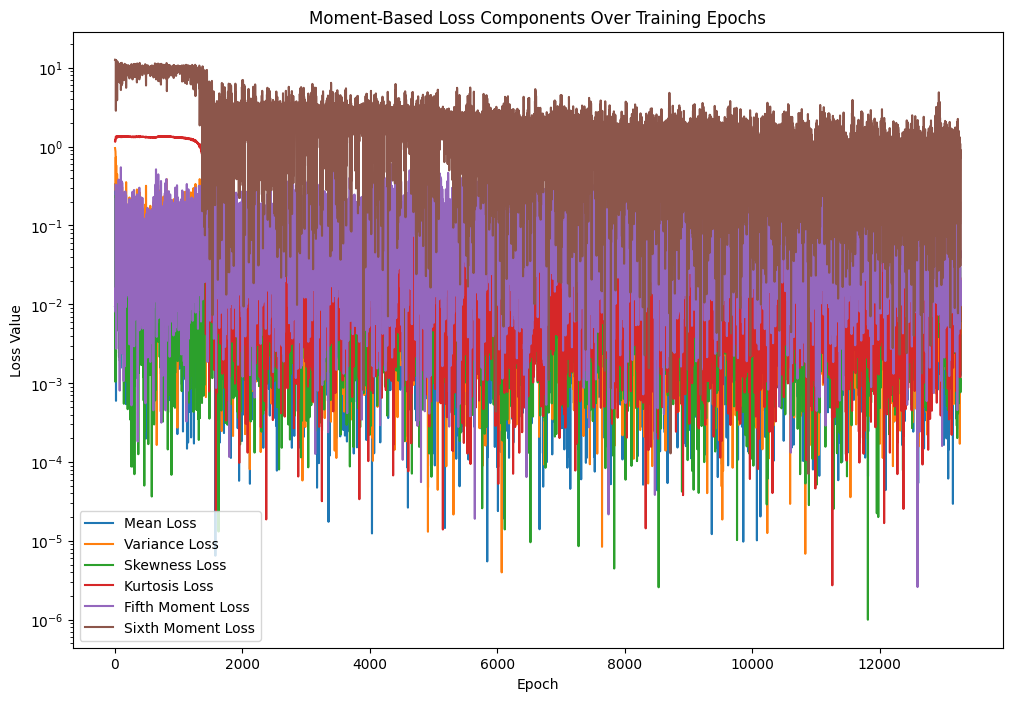

In [20]:
# Plot each loss component
plt.figure(figsize=(12, 8))
plt.yscale('log')
plt.plot(epoch_list, mean_loss_list, label="Mean Loss")
plt.plot(epoch_list, variance_loss_list, label="Variance Loss")
plt.plot(epoch_list, skewness_loss_list, label="Skewness Loss")
plt.plot(epoch_list, kurtosis_loss_list, label="Kurtosis Loss")
plt.plot(epoch_list, fifth_moment_loss_list, label="Fifth Moment Loss")
plt.plot(epoch_list, sixth_moment_loss_list, label="Sixth Moment Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Moment-Based Loss Components Over Training Epochs")
plt.legend()
plt.show()

Text(0, 0.5, '$l_1$')

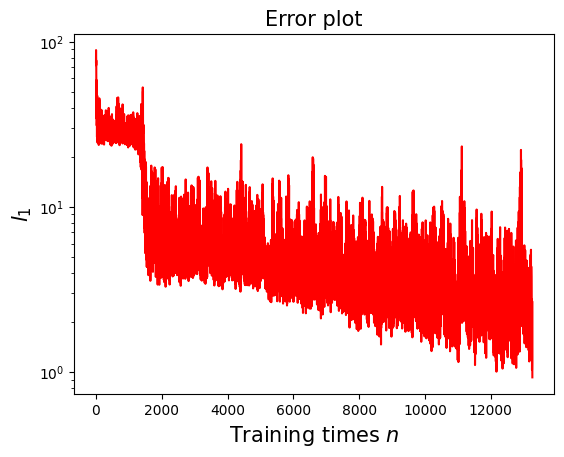

In [21]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, total_loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_1$',fontsize=15)

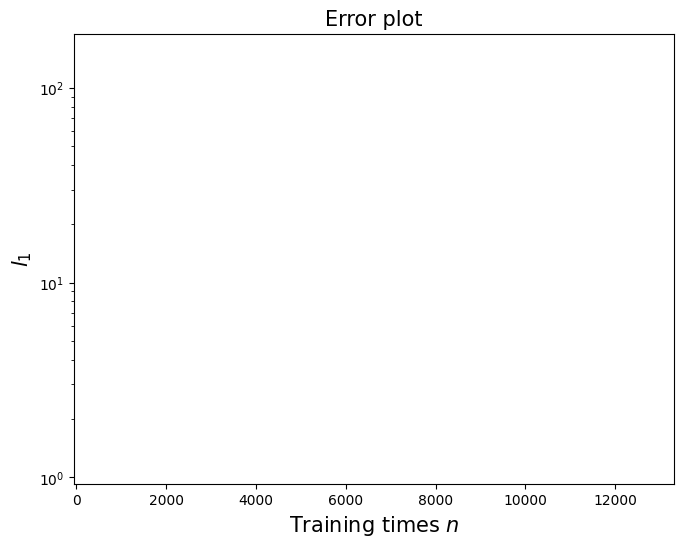

In [22]:
# Initialize figure
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
ax.set_title("Error plot", fontsize=15)
ax.set_xlabel(r'Training times $n$', fontsize=15)
ax.set_ylabel(r'$l_1$', fontsize=15)
ax.set_yscale('log')  # Use logarithmic scale for better visualization
ax.set_xlim(-50, epoch_list[-1]+50)  # Initial x-axis limit
ax.set_ylim(min(total_loss_list)-0.00001, max(total_loss_list)+100)  # Set y-axis limit

# Initialize line plot object (empty initially)
line, = ax.plot([], [], 'r', label='Training error')

# Function to update the plot in the animation
def update_plot(frame):
    # Show 10 more points at each frame
    end_index = (frame + 1) * save_interval
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    
    # Update the line data
    line.set_data(epoch_data, loss_data)
    
    # Update the title to reflect the current epoch range
    ax.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    
    return line,

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // save_interval  # Adjust for how many epochs you have
if len(epoch_list) % save_interval != 0:
    num_frames += 1

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=50, repeat=False)

# Show the animation
plt.show()

# Optionally save the animation as a GIF
anim.save("error_plot_animation.gif", writer="pillow", fps=20)


In [23]:
# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [24]:
# Function to load model and transform samples
def load_and_transform(model, model_path, input_test):
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        transformed_samples = model(input_test)
    return transformed_samples.numpy()

In [25]:
# Get list of saved models sorted by creation time
model_files = sorted(glob.glob("model_epoch_*.pt"), key=os.path.getmtime)

if not model_files:
    print("No model files found.")
else:
    # Collect transformed samples for each saved model
    transformed_samples_list = [load_and_transform(model, path, input_test) for path in model_files]

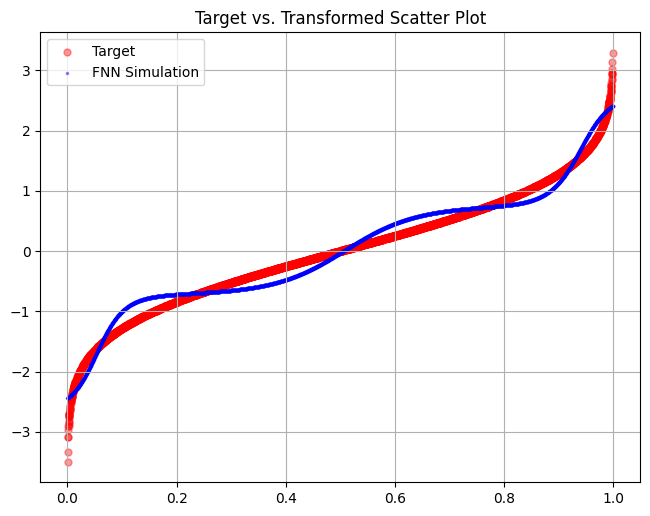

In [26]:
# Set up the figure with two subplots
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

# Scatter plot
scatter_target = ax.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax.legend()
ax.set_title("Target vs. Transformed Scatter Plot")
ax.grid(True)


In [27]:
# Animation function
def animate(i):
    # Update scatter plot for FNN simulation
    epoch = int(model_files[i].split('_')[-1].split('.')[0])
    scatter_sim.set_offsets(np.c_[input_test.numpy(), transformed_samples_list[i]])
    ax.set_title(f"Scatter Plot at Epoch {epoch}")

In [28]:
# Create the animation
anim = FuncAnimation(fig, animate, frames=len(transformed_samples_list), interval=50)
%matplotlib inline
# Display the animation
plt.show()
# Save animation
anim.save("training_animation.gif", writer="pillow", fps=20)

# Combined

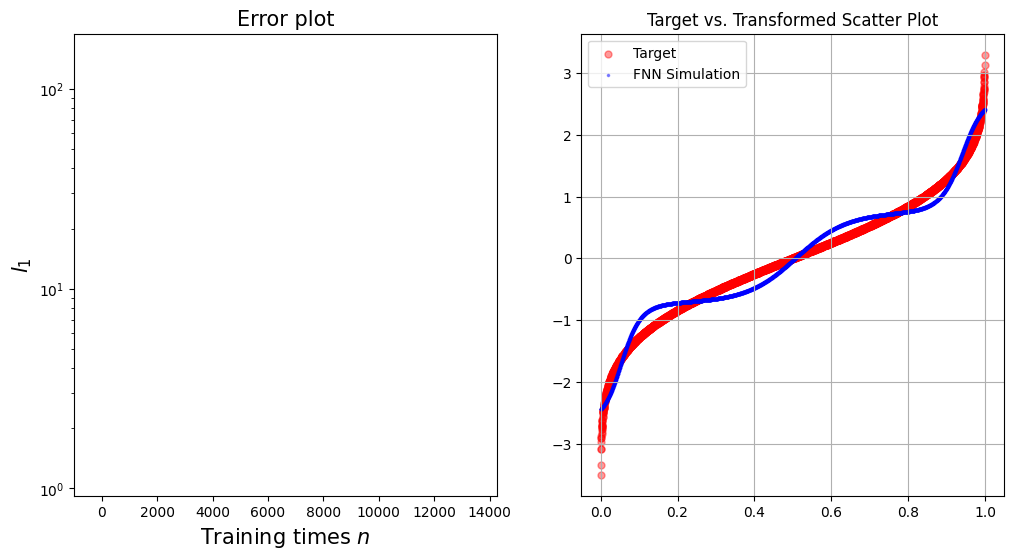

In [36]:
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Total loss plot (ax1)
ax1.set_title("Error plot", fontsize=15)
ax1.set_xlabel(r'Training times $n$', fontsize=15)
ax1.set_ylabel(r'$l_1$', fontsize=15)
ax1.set_yscale('log')  # Use logarithmic scale for better visualization
ax1.set_xlim(-1000, epoch_list[-1]+1000)  # Initial x-axis limit
ax1.set_ylim(min(total_loss_list)-0.01, max(total_loss_list)+100)  # Set y-axis limit
line, = ax1.plot([], [], 'r', label='Training error')

# Scatter plot (ax2)
scatter_target = ax2.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax2.scatter(1-input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax2.legend()
ax2.set_title("Target vs. Transformed Scatter Plot")
ax2.grid(True)

# Function to update both the total loss plot and scatter plot
def update_plot(frame):
    # Update total loss plot (ax1)
    end_index = (frame + 1) * save_interval
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    line.set_data(epoch_data, loss_data)
    
    # Update scatter plot (ax2) for FNN simulation
    scatter_sim.set_offsets(np.c_[1-input_test.numpy(), transformed_samples_list[frame]])
    
    # Update titles
    ax1.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    ax2.set_title(f"Scatter Plot at Epoch {frame * save_interval}", fontsize=15)
    
    return line, scatter_sim  # Return the updated plot elements

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // save_interval  # Adjust for how many epochs you have
if len(epoch_list) % save_interval != 0:
    num_frames += 1

# Create the combined animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=50, repeat=False)

# Show the animation
plt.show()

# Optionally, save the animation as a GIF
anim.save("combined_training_animation.gif", writer="pillow", fps=20)

In [30]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

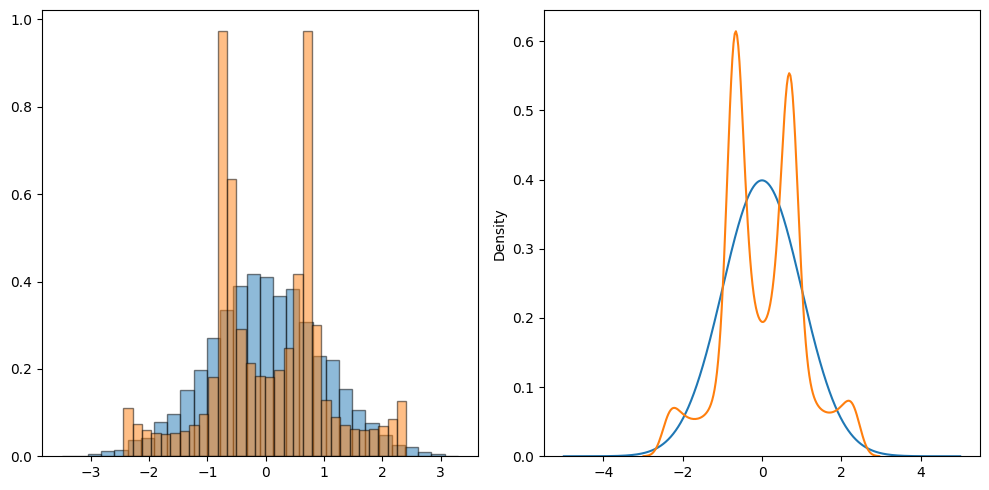

In [31]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

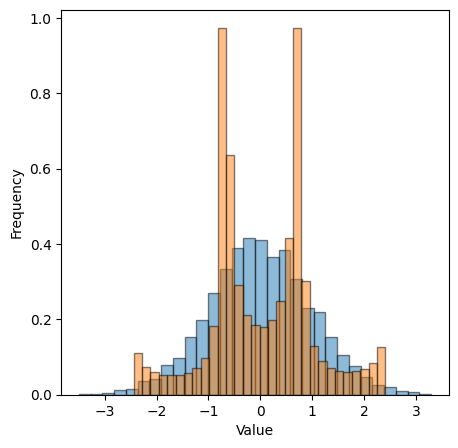

In [32]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

Text(0.5, 0, 'Value')

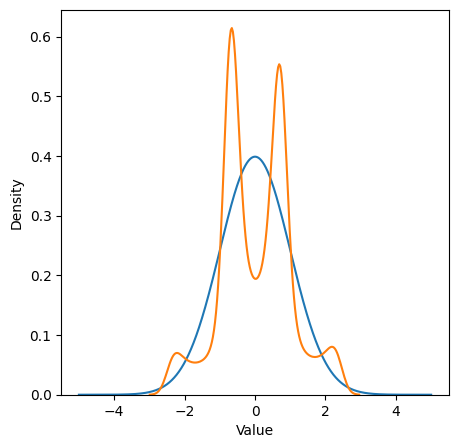

In [33]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')

In [34]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(compute_mean(transformed_samples1))
print(compute_variance(transformed_samples1))
print(compute_skewness(transformed_samples1))
print(compute_kurtosis(transformed_samples1))
print(compute_fifth_moment(transformed_samples1))
print(compute_fifth_moment(transformed_samples1))

tensor(0.0127)
tensor(0.9611)
tensor(0.0039)
tensor(-0.0117)
tensor(-0.0758)
tensor(-0.0758)


In [35]:
print(compute_mean(gaussian_samples))
print(compute_variance(gaussian_samples))
print(compute_skewness(gaussian_samples))
print(compute_kurtosis(gaussian_samples))
print(compute_fifth_moment(gaussian_samples))
print(compute_fifth_moment(gaussian_samples))

tensor(0.0010, dtype=torch.float64)
tensor(0.9571, dtype=torch.float64)
tensor(0.0153, dtype=torch.float64)
tensor(0.0006, dtype=torch.float64)
tensor(-0.0092, dtype=torch.float64)
tensor(-0.0092, dtype=torch.float64)
